# Comparative Study: Shallow CNN vs Deep CNN on Fashion-MNIST

Hands-on notebook: load data, train two architectures, compare metrics, error analysis, and conclusion.

## Part 1: Load and Explore the Dataset (15 marks)

**Brief write-up (after running cells below)**

- **Why normalize?** Neural nets train more stably when inputs are on a similar scale (e.g. \[0,1\]). Large pixel values (0–255) can lead to large gradients and slower or unstable optimization; normalization often speeds convergence and improves numerical conditioning.
- **Why reshape for CNNs?** Conv2D layers expect a *spatial* tensor: batch × **height** × **width** × **channels**. Grayscale Fashion-MNIST is 28×28 with 1 channel, so we add the channel dimension `(N, 28, 28, 1)` instead of `(N, 28, 28)`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print("Number of classes:", len(class_names))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape : (10000, 28, 28)
y_test shape : (10000,)
Number of classes: 10


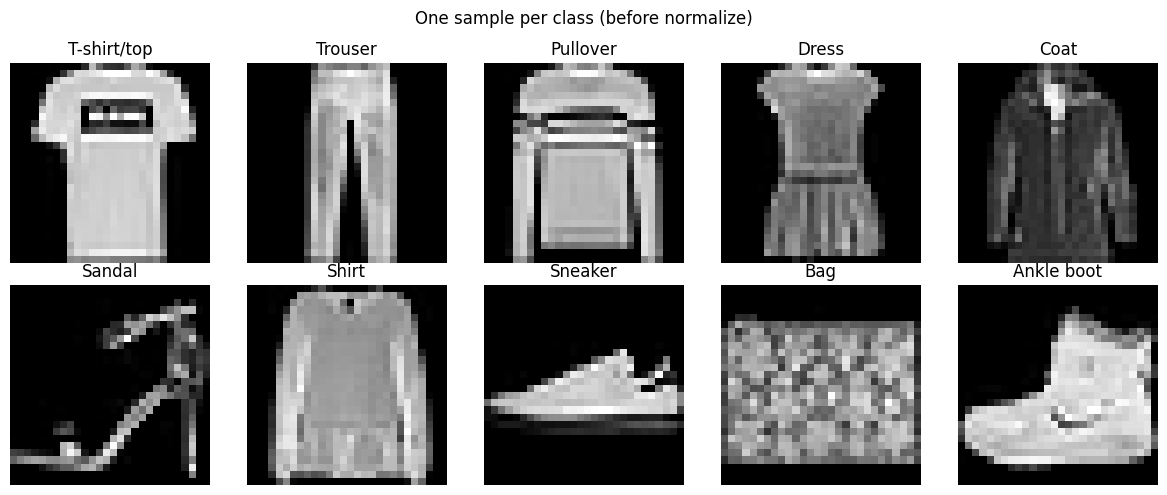

In [2]:
# One sample image per class (from training set)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()
for c in range(10):
    idx = np.where(y_train == c)[0][0]
    axes[c].imshow(x_train[idx], cmap='gray')
    axes[c].set_title(class_names[c])
    axes[c].axis('off')
plt.suptitle('One sample per class (before normalize)')
plt.tight_layout()
plt.show()

In [3]:
# Normalize pixel values to [0, 1] and reshape for Conv2D: (N, H, W, C)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train_cnn = x_train[..., np.newaxis]
x_test_cnn = x_test[..., np.newaxis]

print("After normalize — x_train min/max:", x_train.min(), x_train.max())
print("CNN input shape (train):", x_train_cnn.shape)
print("CNN input shape (test) :", x_test_cnn.shape)

num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

After normalize — x_train min/max: 0.0 1.0
CNN input shape (train): (60000, 28, 28, 1)
CNN input shape (test) : (10000, 28, 28, 1)


## Part 2: Shallow CNN (25 marks)

Architecture: 2 conv layers, 1 max-pool, flatten, 1 dense hidden, softmax output.

**Brief (fill in after training)**
- A shallow CNN mainly learns **local edges, textures, and simple part-like patterns** in early layers; with few layers, hierarchical composition of complex shapes is limited.
- **Underfitting / overfitting:** Compare train vs validation curves. Large gap (train much better than val) → overfitting; both train and val poor → underfitting.

In [4]:
def build_shallow_cnn():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax'),
    ], name='shallow_cnn')
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

shallow_model = build_shallow_cnn()
shallow_model.summary()

Model: "shallow_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 813,802 (3.10 MB)

 Trainable params: 813,802 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
EPOCHS = 15
BATCH = 128
VAL_SPLIT = 0.1

t0 = time.perf_counter()
history_shallow = shallow_model.fit(
    x_train_cnn,
    y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_split=VAL_SPLIT,
    verbose=1,
)
shallow_train_time = time.perf_counter() - t0
print(f"Shallow CNN training time: {shallow_train_time:.2f} s")

shallow_test_loss, shallow_test_acc = shallow_model.evaluate(x_test_cnn, y_test_cat, verbose=0)
print(f"Shallow CNN test accuracy: {shallow_test_acc:.4f}")

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 96ms/step - accuracy: 0.8442 - loss: 0.4480 - val_accuracy: 0.8868 - val_loss: 0.3213
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 35s 83ms/step - accuracy: 0.9012 - loss: 0.2763 - val_accuracy: 0.8968 - val_loss: 0.2733
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 33s 79ms/step - accuracy: 0.9199 - loss: 0.2241 - val_accuracy: 0.9143 - val_loss: 0.2353
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 35s 84ms/step - accuracy: 0.9324 - loss: 0.1872 - val_accuracy: 0.9167 - val_loss: 0.2261
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 34s 81ms/step - accuracy: 0.9412 - loss: 0.1602 - val_accuracy: 0.9187 - val_loss: 0.2330
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 34s 80ms/step - accuracy: 0.9504 - loss: 0.1354 - val_accuracy: 0.9195 - val_loss: 0.2300
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6886s 16s/step - accuracy: 0.9594 - loss: 0.1127 - val_accuracy: 0.9195 - val_loss: 0.2366
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2261s 5s/step - accuracy: 0.9829 - loss: 0.0486 -

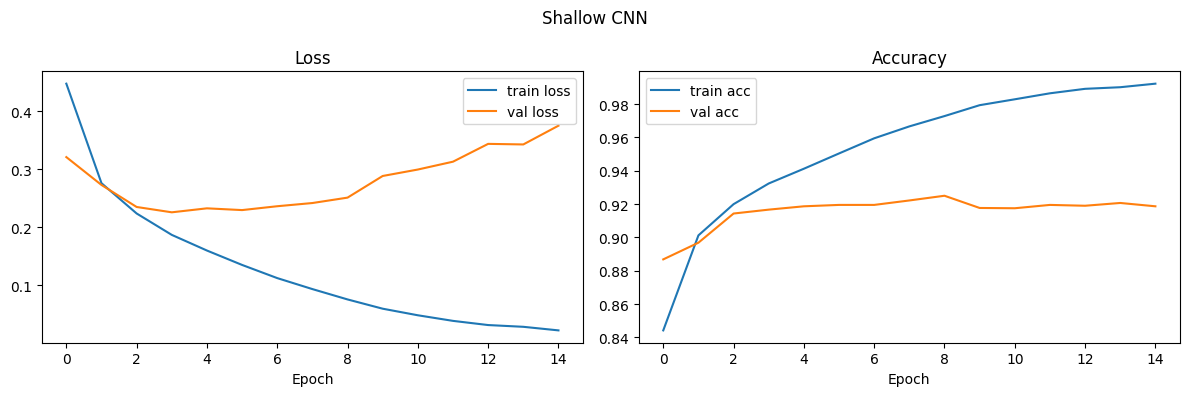

In [6]:
def plot_history(history, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history.history['loss'], label='train loss')
    ax[0].plot(history.history['val_loss'], label='val loss')
    ax[0].set_title('Loss')
    ax[0].set_xlabel('Epoch')
    ax[0].legend()
    ax[1].plot(history.history['accuracy'], label='train acc')
    ax[1].plot(history.history['val_accuracy'], label='val acc')
    ax[1].set_title('Accuracy')
    ax[1].set_xlabel('Epoch')
    ax[1].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history(history_shallow, 'Shallow CNN')

## Part 3: Deep CNN (25 marks)

More conv layers, multiple pooling stages, more filters, extra dense layer.

**Brief**
- Deeper stacks can learn **hierarchical features**: edges → textures → parts → class-specific shapes.
- Check if **test accuracy** and **val–train gap** improved vs shallow model to judge if depth "meaningfully" helped.

In [7]:
def build_deep_cnn():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax'),
    ], name='deep_cnn')
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

deep_model = build_deep_cnn()
deep_model.summary()

Model: "deep_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 14, 14, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 14, 14, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │       1,605,888 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,899,082 (7.24 MB)

 Trainable params: 1,899,082 (7.24 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
t0 = time.perf_counter()
history_deep = deep_model.fit(
    x_train_cnn,
    y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_split=VAL_SPLIT,
    verbose=1,
)
deep_train_time = time.perf_counter() - t0
print(f"Deep CNN training time: {deep_train_time:.2f} s")

deep_test_loss, deep_test_acc = deep_model.evaluate(x_test_cnn, y_test_cat, verbose=0)
print(f"Deep CNN test accuracy: {deep_test_acc:.4f}")

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 29s 68ms/step - accuracy: 0.8231 - loss: 0.4801 - val_accuracy: 0.8773 - val_loss: 0.3142
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 63ms/step - accuracy: 0.9000 - loss: 0.2732 - val_accuracy: 0.9130 - val_loss: 0.2409
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 29s 70ms/step - accuracy: 0.9185 - loss: 0.2229 - val_accuracy: 0.9183 - val_loss: 0.2315
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 93ms/step - accuracy: 0.9288 - loss: 0.1940 - val_accuracy: 0.9272 - val_loss: 0.2082
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 59s 139ms/step - accuracy: 0.9391 - loss: 0.1659 - val_accuracy: 0.9208 - val_loss: 0.2080
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 50s 119ms/step - accuracy: 0.9472 - loss: 0.1436 - val_accuracy: 0.9265 - val_loss: 0.2032
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 61s 144ms/step - accuracy: 0.9538 - loss: 0.1242 - val_accuracy: 0.9288 - val_loss: 0.2012
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 59s 139ms/step - accuracy: 0.9612 - loss: 0.105

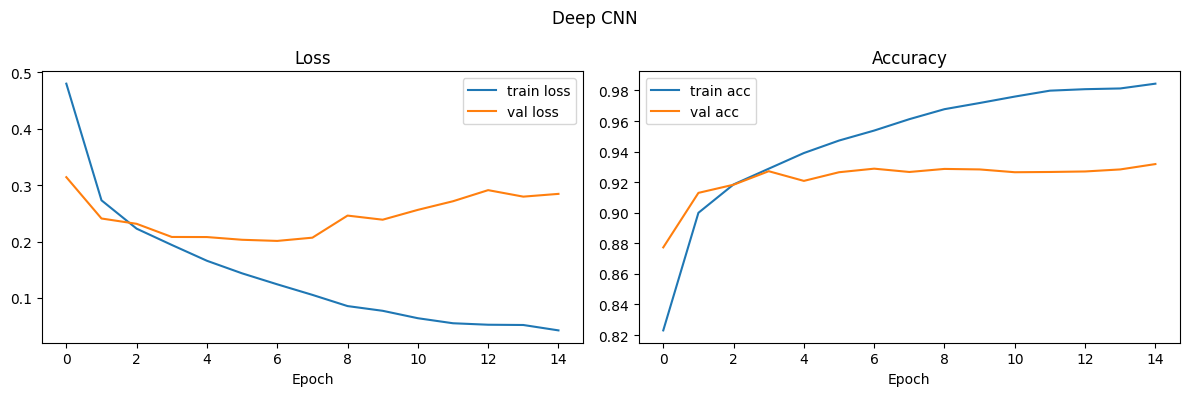

In [9]:
plot_history(history_deep, 'Deep CNN')

## Part 4: Comparative Study (20 marks)

Same data, same `EPOCHS`, `BATCH`, and `validation_split` for a fair comparison. **Edit the markdown table** after a run if you want prose tied to exact numbers from your machine.

In [10]:
def count_conv_layers(model):
    return sum(1 for l in model.layers if 'conv' in l.name.lower() or isinstance(l, layers.Conv2D))

def final_train_val_acc(history):
    return history.history['accuracy'][-1], history.history['val_accuracy'][-1]

def overfitting_flag(history, thresh=0.03):
    ta, va = final_train_val_acc(history)
    return (ta - va) > thresh

st_train_acc, st_val_acc = final_train_val_acc(history_shallow)
dp_train_acc, dp_val_acc = final_train_val_acc(history_deep)

try:
    from IPython.display import display
except ImportError:
    display = print

comparison = pd.DataFrame({
    'Metric': [
        'Number of Conv Layers',
        'Total Parameters',
        'Training Accuracy (final epoch)',
        'Validation Accuracy (final epoch)',
        'Test Accuracy',
        'Overfitting Observed? (train−val > 0.03)',
        'Training Time (s)',
    ],
    'Shallow CNN': [
        count_conv_layers(shallow_model),
        f"{shallow_model.count_params():,}",
        f"{st_train_acc:.4f}",
        f"{st_val_acc:.4f}",
        f"{shallow_test_acc:.4f}",
        'Yes' if overfitting_flag(history_shallow) else 'No',
        f"{shallow_train_time:.2f}",
    ],
    'Deep CNN': [
        count_conv_layers(deep_model),
        f"{deep_model.count_params():,}",
        f"{dp_train_acc:.4f}",
        f"{dp_val_acc:.4f}",
        f"{deep_test_acc:.4f}",
        'Yes' if overfitting_flag(history_deep) else 'No',
        f"{deep_train_time:.2f}",
    ],
})
display(comparison)

,Metric,Shallow CNN,Deep CNN
0,Number of Conv Layers,2,4
1,Total Parameters,"813,802","1,899,082"
2,Training Accuracy (final epoch),0.9922,0.9844
3,Validation Accuracy (final epoch),0.9187,0.9318
4,Test Accuracy,0.9169,0.9323
5,Overfitting Observed? (train−val > 0.03),Yes,Yes
6,Training Time (s),9668.94,820.94


### Short answers (Part 4)

- **Which performed better overall?** Compare **test accuracy** and **validation accuracy** in the table above.
- **Did deep CNN justify complexity?** If test gain is small but parameters and time are much larger, the trade-off may not be worth it for this dataset.
- **Which generalized better?** Prefer the model with **higher test accuracy** and **smaller train–val gap** (less overfitting).
- **Simplicity vs performance:** Shallow nets are faster and easier to tune; deep nets can extract richer features at the cost of compute and overfitting risk on small/simple data.

## Part 5: Prediction and Error Analysis (15 marks)

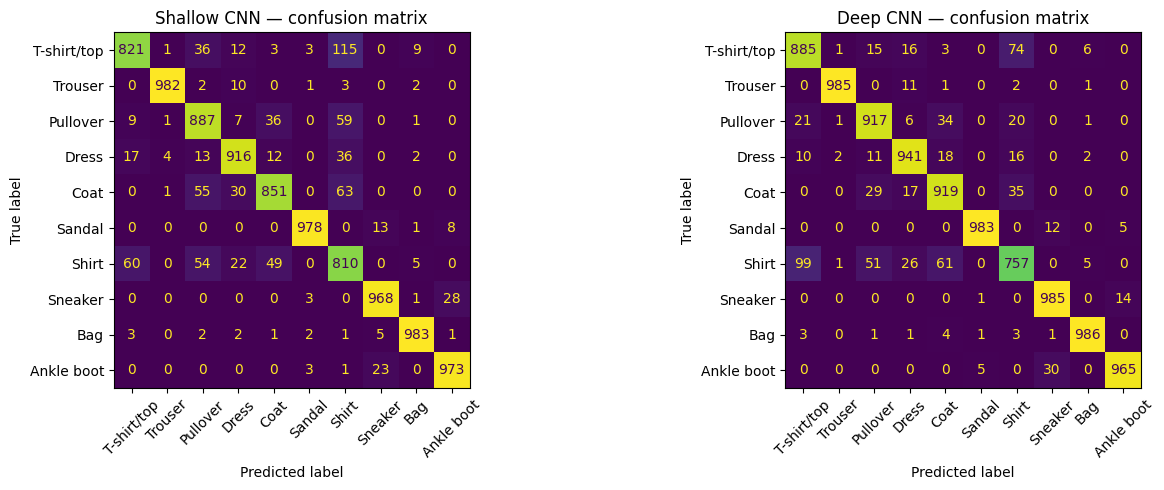

In [11]:
def predict_labels(model, x):
    prob = model.predict(x, verbose=0)
    return np.argmax(prob, axis=1)

y_pred_shallow = predict_labels(shallow_model, x_test_cnn)
y_pred_deep = predict_labels(deep_model, x_test_cnn)

cm_s = confusion_matrix(y_test, y_pred_shallow)
cm_d = confusion_matrix(y_test, y_pred_deep)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm_s, display_labels=class_names).plot(ax=ax[0], xticks_rotation=45, colorbar=False)
ax[0].set_title('Shallow CNN — confusion matrix')
ConfusionMatrixDisplay(cm_d, display_labels=class_names).plot(ax=ax[1], xticks_rotation=45, colorbar=False)
ax[1].set_title('Deep CNN — confusion matrix')
plt.tight_layout()
plt.show()

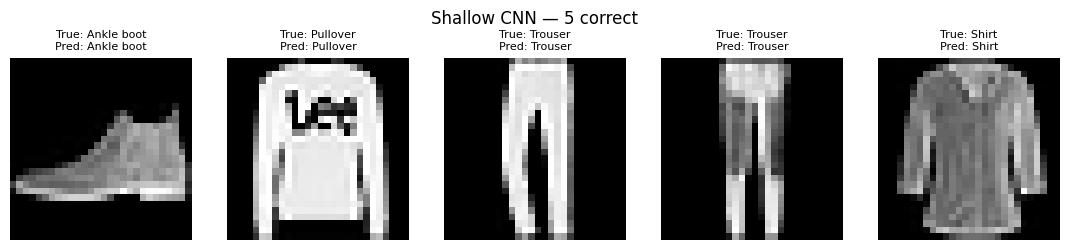

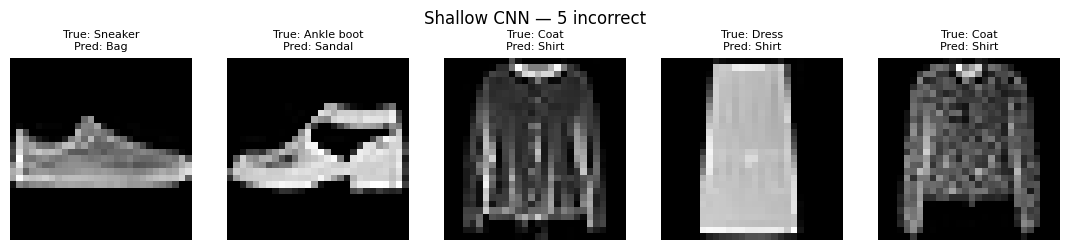

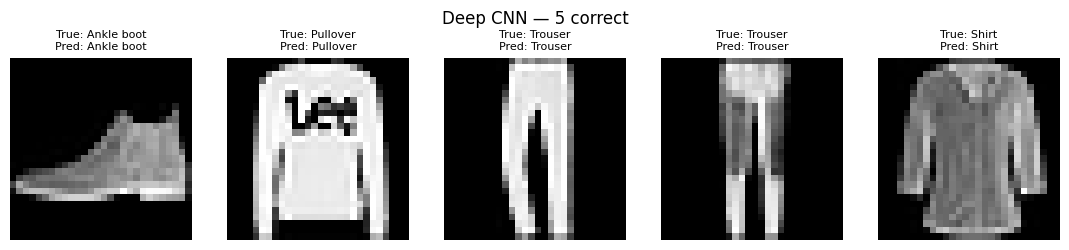

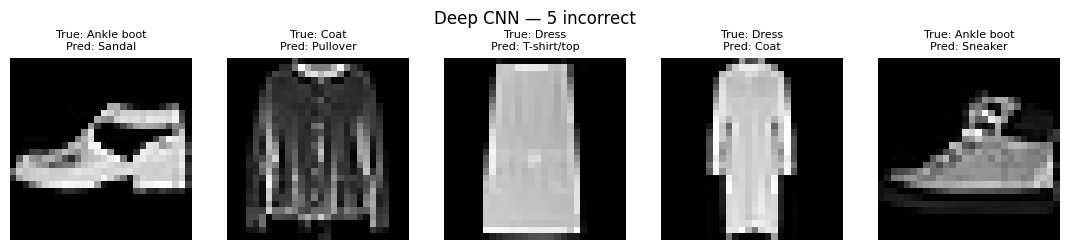

In [12]:
def show_predictions(x_images, y_true, y_pred, correct, n=5, title=''):
    """If correct=True, show n correctly classified; else n misclassified."""
    mask = (y_pred == y_true) if correct else (y_pred != y_true)
    idxs = np.where(mask)[0][:n]
    fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.5))
    if n == 1:
        axes = [axes]
    for ax, i in zip(axes, idxs):
        ax.imshow(x_images[i].squeeze(), cmap='gray')
        ax.set_title(f"True: {class_names[y_true[i]]}\nPred: {class_names[y_pred[i]]}", fontsize=8)
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

# Shallow: 5 correct, 5 wrong
show_predictions(x_test_cnn, y_test, y_pred_shallow, correct=True, n=5, title='Shallow CNN — 5 correct')
show_predictions(x_test_cnn, y_test, y_pred_shallow, correct=False, n=5, title='Shallow CNN — 5 incorrect')

# Deep: 5 correct, 5 wrong
show_predictions(x_test_cnn, y_test, y_pred_deep, correct=True, n=5, title='Deep CNN — 5 correct')
show_predictions(x_test_cnn, y_test, y_pred_deep, correct=False, n=5, title='Deep CNN — 5 incorrect')

### Brief (Part 5) — interpret your confusion matrices

- **Easiest classes:** Usually **diagonal** entries with highest recall (large values on diagonal for that row/class).
- **Most confused pairs:** Large **off-diagonal** entries, e.g. Shirt vs T-shirt/top, Coat vs Pullover, Sneaker vs Ankle boot are common on Fashion-MNIST.
- **Did deep CNN reduce confusion?** Compare off-diagonal mass between the two matrices; if deep model’s errors concentrate less on ambiguous pairs, it helped disambiguate similar classes.

## Part 6: Final Comparative Conclusion (10 marks)

**Template — replace bracketed parts after you run the notebook.**

1. **Recommendation for Fashion-MNIST:** I would recommend **[shallow / deep]** because **[higher test accuracy / similar accuracy with lower cost / less overfitting]**.
2. **More efficient:** **[Shallow / Deep]** used **[less / more]** training time and **[fewer / more]** parameters.
3. **More accurate:** **[Shallow / Deep]** achieved higher **test** accuracy (**[…]** vs **[…]**).
4. **What I learned:** Depth increases representational power but does not always improve generalization on small 28×28 images; matching model capacity to data and monitoring train/val gap is essential.

---

**Deliverable note:** The assignment also asks for a **short comparative report** (PDF/Word) summarizing objective, dataset, comparison, observations, and conclusion — you can export this notebook to PDF or copy sections into a report document.